In [1]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [2]:
# Check the size of the dataset
print("Dataset shape:", df.shape)

# Check column names
print("\nColumns:")
print(df.columns.tolist())

# Check data types and missing values
print("\nDataset information:")
df.info()

Dataset shape: (1470, 35)

Columns:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTr

In [3]:
# Check for missing values
print("Total missing values:", df.isnull().sum().sum())

# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Check unique values in the target variable
print("\nAttrition values:")
print(df["Attrition"].value_counts())

Total missing values: 0
Duplicate rows: 0

Attrition values:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [4]:
# Calculate overall attrition rate
attrition_rate = (df["Attrition"] == "Yes").mean() * 100

print(f"Overall Attrition Rate: {attrition_rate:.2f}%")

Overall Attrition Rate: 16.12%


In [5]:
# Calculate attrition rate by overtime status
overtime_attrition = (
    df.groupby("OverTime")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
)

print("Attrition Rate by Overtime:")
print(overtime_attrition)

Attrition Rate by Overtime:
OverTime
No     10.44
Yes    30.53
Name: Attrition, dtype: float64


In [6]:
# Compare average monthly income by attrition status
income_attrition = (
    df.groupby("Attrition")["MonthlyIncome"]
      .mean()
      .round(2)
)

print("Average Monthly Income by Attrition:")
print(income_attrition)

Average Monthly Income by Attrition:
Attrition
No     6832.74
Yes    4787.09
Name: MonthlyIncome, dtype: float64


In [7]:
# Compare average age by attrition status
age_attrition = (
    df.groupby("Attrition")["Age"]
      .mean()
      .round(2)
)

print("Average Age by Attrition:")
print(age_attrition)

Average Age by Attrition:
Attrition
No     37.56
Yes    33.61
Name: Age, dtype: float64


In [8]:
# Compare average job satisfaction by attrition status
satisfaction_attrition = (
    df.groupby("Attrition")["JobSatisfaction"]
      .mean()
      .round(2)
)

print("Average Job Satisfaction by Attrition:")
print(satisfaction_attrition)

Average Job Satisfaction by Attrition:
Attrition
No     2.78
Yes    2.47
Name: JobSatisfaction, dtype: float64


In [9]:
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'matplotlib'

In [10]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


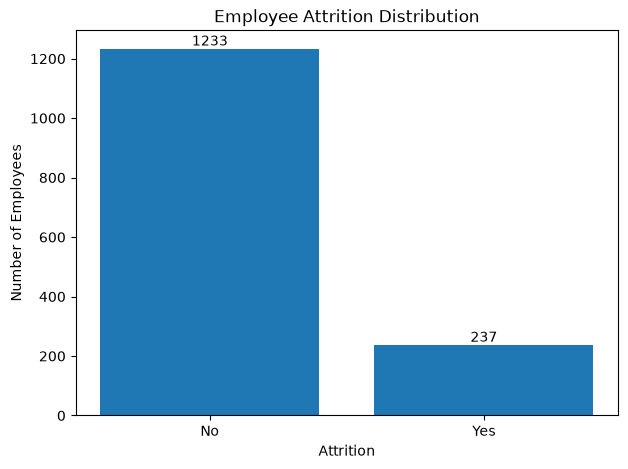

In [11]:
# Visualize overall employee attrition

attrition_counts = df["Attrition"].value_counts()

plt.figure(figsize=(7, 5))
bars = plt.bar(attrition_counts.index, attrition_counts.values)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha="center",
        va="bottom"
    )

plt.show()

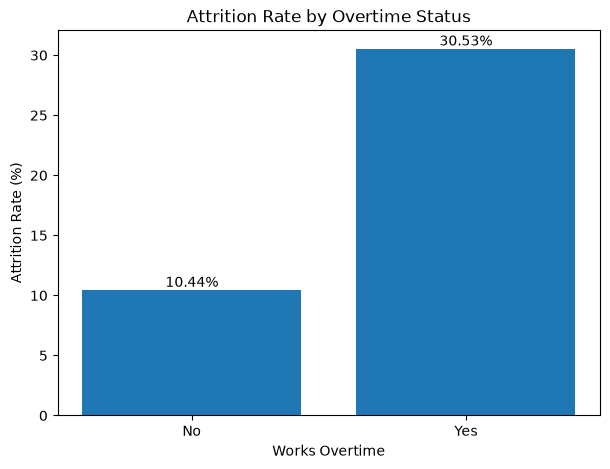

In [12]:
# Visualize attrition rate by overtime

plt.figure(figsize=(7, 5))

bars = plt.bar(
    overtime_attrition.index,
    overtime_attrition.values
)

plt.title("Attrition Rate by Overtime Status")
plt.xlabel("Works Overtime")
plt.ylabel("Attrition Rate (%)")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom"
    )

plt.show()

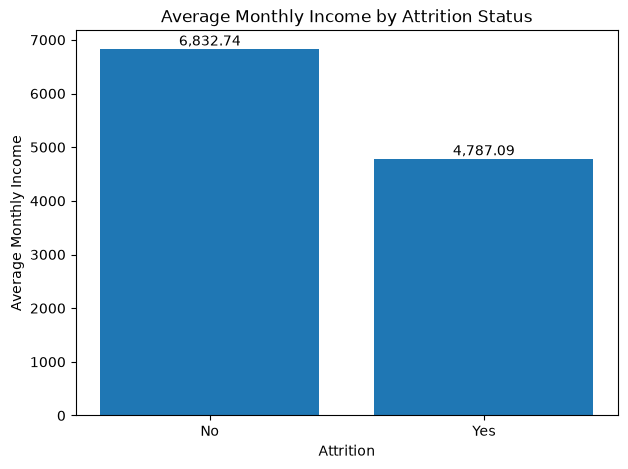

In [13]:
# Visualize average monthly income by attrition status

plt.figure(figsize=(7, 5))

bars = plt.bar(
    income_attrition.index,
    income_attrition.values
)

plt.title("Average Monthly Income by Attrition Status")
plt.xlabel("Attrition")
plt.ylabel("Average Monthly Income")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.2f}",
        ha="center",
        va="bottom"
    )

plt.show()

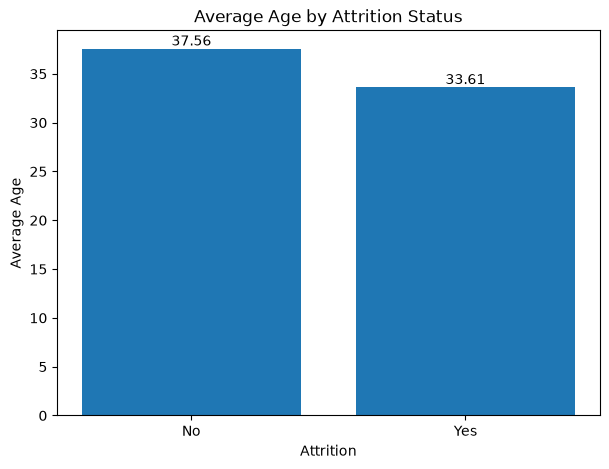

In [14]:
# Visualize average age by attrition status

plt.figure(figsize=(7, 5))

bars = plt.bar(
    age_attrition.index,
    age_attrition.values
)

plt.title("Average Age by Attrition Status")
plt.xlabel("Attrition")
plt.ylabel("Average Age")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha="center",
        va="bottom"
    )

plt.show()

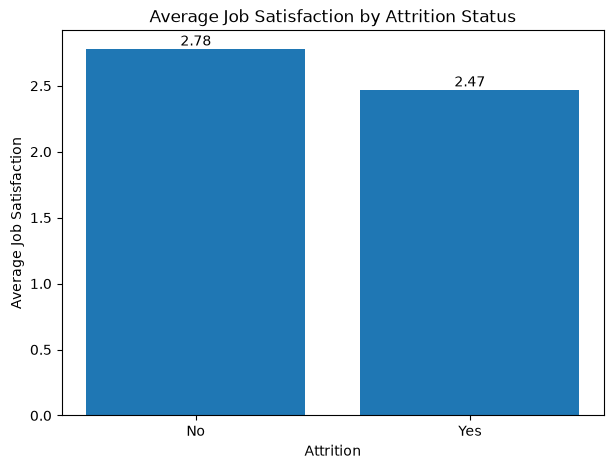

In [15]:
# Visualize average job satisfaction by attrition status

plt.figure(figsize=(7, 5))

bars = plt.bar(
    satisfaction_attrition.index,
    satisfaction_attrition.values
)

plt.title("Average Job Satisfaction by Attrition Status")
plt.xlabel("Attrition")
plt.ylabel("Average Job Satisfaction")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha="center",
        va="bottom"
    )

plt.show()

In [16]:
# Calculate attrition rate by department

department_attrition = (
    df.groupby("Department")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
    .round(2)
)

print("Attrition Rate by Department:")
print(department_attrition)

Attrition Rate by Department:
Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: float64


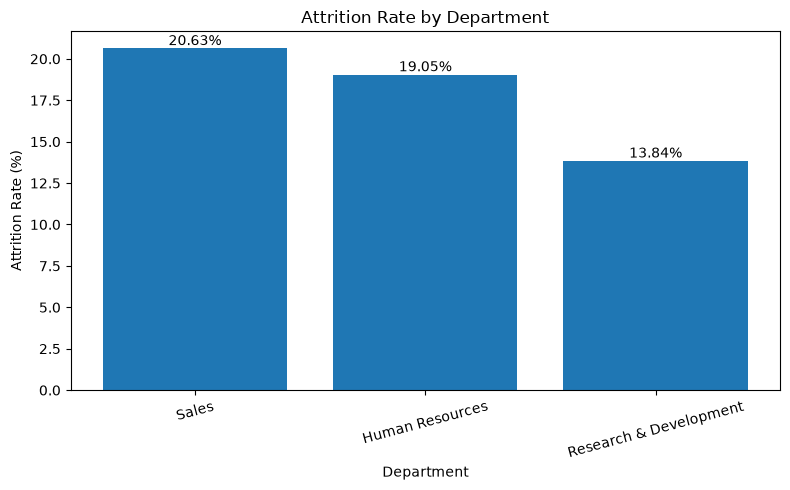

In [17]:
# Visualize attrition rate by department

plt.figure(figsize=(8, 5))

bars = plt.bar(
    department_attrition.index,
    department_attrition.values
)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [18]:
# Calculate attrition rate by job role

jobrole_attrition = (
    df.groupby("JobRole")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
    .round(2)
)

print("Attrition Rate by Job Role:")
print(jobrole_attrition)

Attrition Rate by Job Role:
JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition, dtype: float64


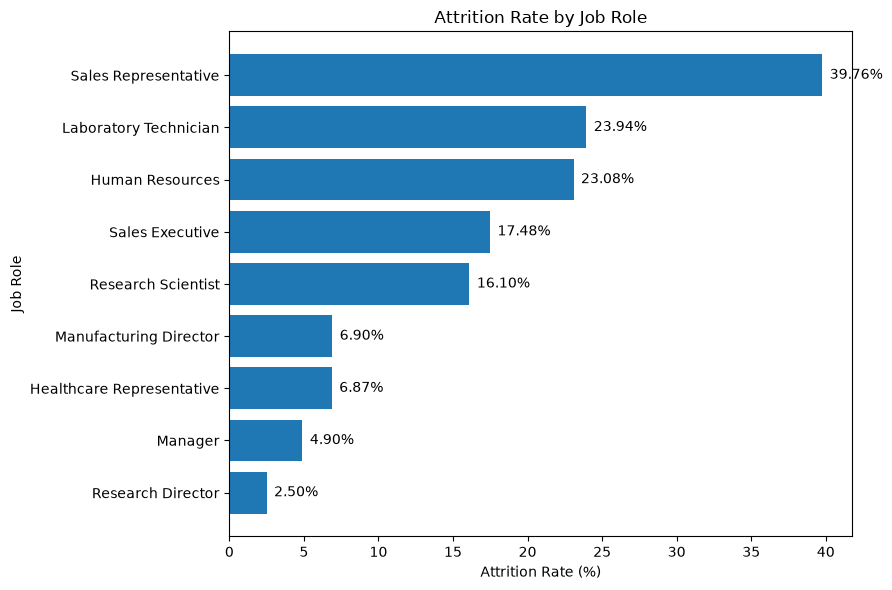

In [19]:
# Visualize attrition rate by job role

plt.figure(figsize=(9, 6))

jobrole_chart = jobrole_attrition.sort_values()

bars = plt.barh(
    jobrole_chart.index,
    jobrole_chart.values
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")

for bar in bars:
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

In [20]:
# Compare average years at company by attrition status

tenure_attrition = (
    df.groupby("Attrition")["YearsAtCompany"]
    .mean()
    .round(2)
)

print("Average Years at Company by Attrition:")
print(tenure_attrition)

Average Years at Company by Attrition:
Attrition
No     7.37
Yes    5.13
Name: YearsAtCompany, dtype: float64


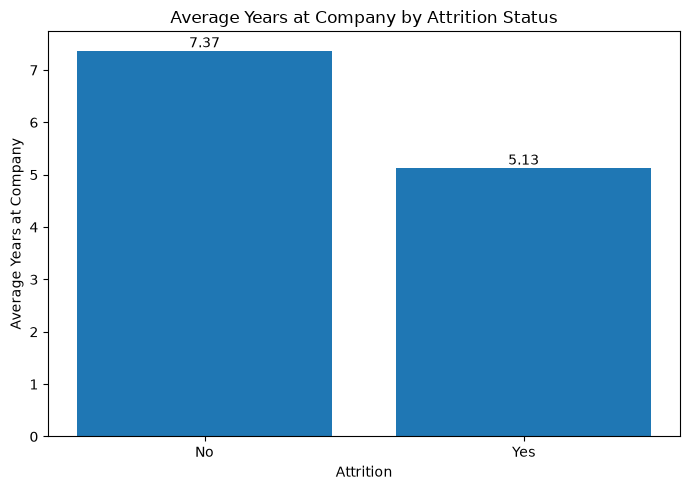

In [21]:
# Visualize average years at company by attrition status

plt.figure(figsize=(7,5))

bars = plt.bar(
    tenure_attrition.index,
    tenure_attrition.values
)

plt.title("Average Years at Company by Attrition Status")
plt.xlabel("Attrition")
plt.ylabel("Average Years at Company")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## Key Findings

The employee attrition analysis identified several important patterns:

- The overall employee attrition rate is **16.12%**, with 237 of 1,470 employees leaving the company.
- Employees who work overtime have an attrition rate of **30.53%**, compared with only **10.44%** among employees who do not work overtime.
- Employees who left earned an average monthly income of **4,787.09**, compared with **6,832.74** for employees who remained.
- Employees who left were younger on average (**33.61 years**) than employees who stayed (**37.56 years**).
- Average job satisfaction was lower among employees who left (**2.47**) compared with employees who stayed (**2.78**).
- The **Sales department** recorded the highest attrition rate at **20.63%**, followed by Human Resources at 19.05%.
- **Sales Representatives** had the highest attrition rate of all job roles at **39.76%**.
- Employees who left had worked at the company for an average of **5.13 years**, compared with **7.37 years** for employees who stayed.

## Business Recommendations

Based on the analysis, the company should consider:

1. **Reviewing overtime workloads** – Overtime shows one of the strongest differences in attrition rates and may indicate workload or work-life balance concerns.
2. **Focusing retention efforts on Sales Representatives** – This role has the highest observed attrition rate and should be investigated further.
3. **Reviewing compensation and career progression** – Employees who leave have lower average monthly income, suggesting compensation and advancement opportunities may warrant further investigation.
4. **Strengthening early-tenure retention** – Employees who leave have shorter average tenure, so onboarding, mentoring and career-development initiatives may improve retention.
5. **Monitoring employee satisfaction** – Regular engagement surveys and manager check-ins could help identify dissatisfaction before employees decide to leave.

## Conclusion

The analysis suggests that employee attrition is associated with several workforce characteristics, particularly overtime, job role, income, age, job satisfaction and tenure. Overtime and Sales Representative roles stand out as areas requiring particular attention.

These findings show associations rather than proving that any individual factor causes employees to leave. Further analysis could be used to identify the strongest predictors of attrition and support more targeted employee-retention strategies.

